# 🏥 Clinical Early Warning System — Deep Learning Pipeline
**Department of Artificial Intelligence | Complex Computing Problem**

This notebook implements all three generations of models:
- **Generation 1**: DNN Baseline (SGD vs Adam, Dropout, BatchNorm)
- **Generation 2**: LSTM / Bi-LSTM / GRU on time-series vital signs
- **Generation 3**: ClinicalBERT fine-tuning on clinical notes
- **Unified comparison table + confusion matrices**

## 0. Crash Prevention & Setup

In [1]:
# ═══════════════════════════════════════════════════
#  CRASH PREVENTION CELL — Run this after cell 0
# ═══════════════════════════════════════════════════
import gc, os, torch
from IPython.display import display, Javascript

# 1. Memory cleaner function
def clear_memory():
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        print(f"GPU free: {torch.cuda.memory_reserved()/1e9:.2f} GB")

# 2. Lightweight checkpoint (saves locally in Colab)
CKPT_DIR = '/content/checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)

def save_ckpt(model, name):
    torch.save(model.state_dict(), f'{CKPT_DIR}/{name}.pt')
    print(f"Saved: {name}")

def load_ckpt(model, name):
    path = f'{CKPT_DIR}/{name}.pt'
    if os.path.exists(path):
        model.load_state_dict(torch.load(path))
        print(f"Loaded: {name}")
        return True
    return False

# 3. Reduce ClinicalBERT memory usage
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

# 4. Keep Colab alive
display(Javascript('''
    function keepAlive() {
        var btn = document.querySelector("colab-toolbar-button#connect");
        if(btn) btn.click();
        console.log("Colab kept alive:", new Date().toLocaleTimeString());
    }
    setInterval(keepAlive, 55000);
'''))

# 5. GPU status
print("="*40)
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("No GPU found — running on CPU")
print("="*40)
print("✅ All crash fixes applied!")

<IPython.core.display.Javascript object>

GPU: Tesla T4
Total VRAM: 15.6 GB
✅ All crash fixes applied!


In [2]:
# Install all required packages — run once
import subprocess, sys

packages = [
    'torch', 'torchvision', 'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn', 'transformers', 'datasets',
    'imbalanced-learn', 'tqdm', 'bertviz'
]
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages installed.')

All packages installed.


## 1. Imports & Global Configuration

In [3]:
import os, warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoConfig
)
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

Using device: cuda


## 2. Data Loading & Exploration

In [4]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Place your Dataset.csv in the same folder as this notebook.
DATA_PATH = 'Dataset.csv'  # ← change if your file is elsewhere

df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print('\nColumn dtypes:')
print(df.dtypes)
print('\nClass distribution:')
print(df['SepsisLabel'].value_counts())
df.head()

Dataset shape: (535602, 44)

Column dtypes:
Unnamed: 0            int64
Hour                  int64
HR                  float64
O2Sat               float64
Temp                float64
SBP                 float64
MAP                 float64
DBP                 float64
Resp                float64
EtCO2               float64
BaseExcess          float64
HCO3                float64
FiO2                float64
pH                  float64
PaCO2               float64
SaO2                float64
AST                 float64
BUN                 float64
Alkalinephos        float64
Calcium             float64
Chloride            float64
Creatinine          float64
Bilirubin_direct    float64
Glucose             float64
Lactate             float64
Magnesium           float64
Phosphate           float64
Potassium           float64
Bilirubin_total     float64
TroponinI           float64
Hct                 float64
Hgb                 float64
PTT                 float64
WBC                 float64
Fibr

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,1.0,0.0,17072.0
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,2.0,0.0,17072.0
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,3.0,0.0,17072.0
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,4.0,0.0,17072.0
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0.0,NaN,NaN,-0.02,5.0,0.0,17072.0


Missing values (%):
EtCO2               100.000000
TroponinI            99.873974
Bilirubin_direct     99.849702
Fibrinogen           99.233946
Bilirubin_total      98.770169
Alkalinephos         98.544815
AST                  98.502619
Lactate              96.582724
PTT                  95.149010
SaO2                 95.110735
Calcium              95.020930
Phosphate            94.943634
Platelets            93.478553
Creatinine           93.368023
WBC                  92.497788
Magnesium            92.233972
HCO3                 91.962315
BUN                  91.856266
Chloride             91.702608
PaCO2                91.292415
Hgb                  91.189353
BaseExcess           89.655752
Potassium            89.195522
pH                   88.610386
Hct                  88.208035
Glucose              87.863936
FiO2                 85.959537
Temp                 66.215772
Unit2                49.625842
Unit1                49.625842
DBP                  47.906841
SBP                

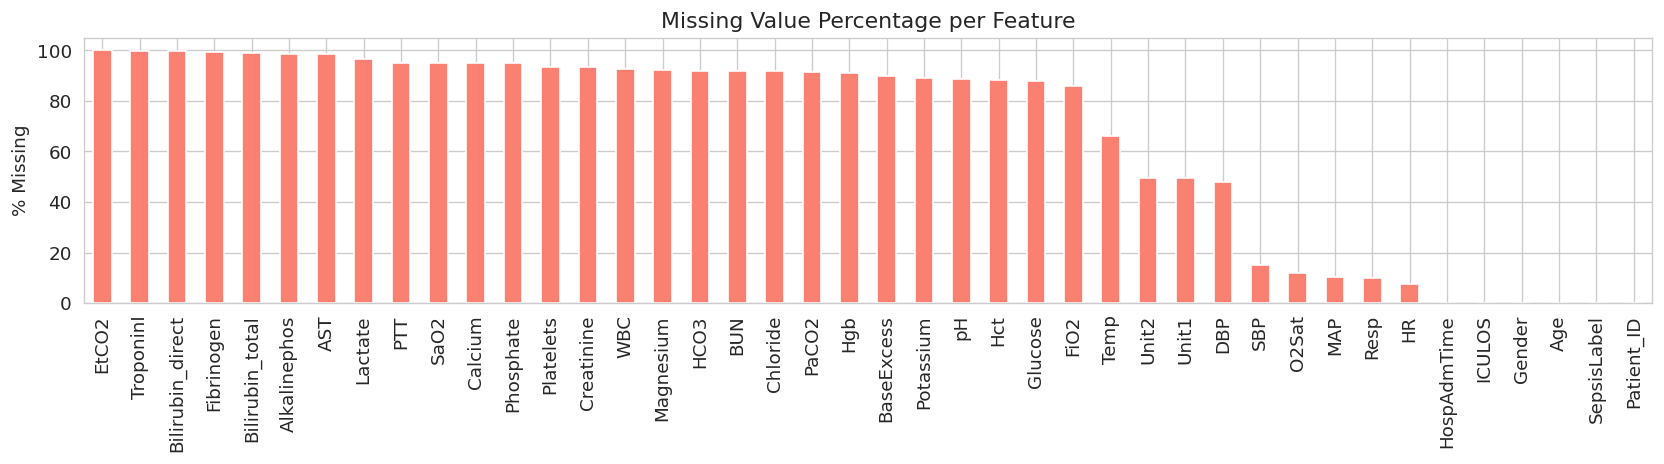

In [5]:
# ── Missing value audit ───────────────────────────────────────────────────────
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print('Missing values (%):')
print(missing_pct[missing_pct > 0].to_string())

fig, ax = plt.subplots(figsize=(14, 4))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='salmon')
ax.set_title('Missing Value Percentage per Feature')
ax.set_ylabel('% Missing')
plt.tight_layout()
plt.show()

## 3. Preprocessing (shared for Gen 1 & Gen 2)

In [6]:
# ── Feature selection ─────────────────────────────────────────────────────────
VITAL_COLS = [
    'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2',
    'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST',
    'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine',
    'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium',
    'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI',
    'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets',
    'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS'
]

TARGET = 'SepsisLabel'

# Keep only columns that actually exist in the dataset
available_vital = [c for c in VITAL_COLS if c in df.columns]
print(f'Using {len(available_vital)} feature columns')

X_raw = df[available_vital].copy()
y_raw = df[TARGET].values

Using 40 feature columns


In [7]:
# ── Imputation ────────────────────────────────────────────────────────────────
# DESIGN DECISION: Median imputation is robust to outliers in vital-sign
# distributions (e.g., extreme heart-rate readings in critically ill patients).
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

# ── FIX: derive column names from imputer output, not available_vital ─────────
# SimpleImputer silently drops all-NaN columns; get_feature_names_out()
# returns only columns that survived, keeping shape aligned with X_imputed.
surviving_cols = imputer.get_feature_names_out(available_vital)

# ── Encode binary categoricals (Gender: M=1, F=0) ────────────────────────────
X_df = pd.DataFrame(X_imputed, columns=surviving_cols)
for col in X_df.select_dtypes(include='object').columns:
    X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

# ── Normalisation ─────────────────────────────────────────────────────────────
# StandardScaler (z-score): zero mean, unit variance per feature.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df)

# Update available_vital to reflect surviving columns only
available_vital = list(surviving_cols)

print(f'Columns after imputation: {len(available_vital)}')
print(f'Feature matrix shape: {X_scaled.shape}')
print(f'Label distribution — 0 (stable): {(y_raw==0).sum()}  |  1 (sepsis): {(y_raw==1).sum()}')

Columns after imputation: 39
Feature matrix shape: (535602, 39)
Label distribution — 0 (stable): 524002  |  1 (sepsis): 11599


In [8]:
# ── FIX: Drop rows where SepsisLabel is NaN before splitting ──────────────────
# y_raw may contain NaN where SepsisLabel was missing in the raw CSV.
# train_test_split with stratify= fails on NaN labels.
valid_mask = ~np.isnan(y_raw)
X_scaled   = X_scaled[valid_mask]
y_raw      = y_raw[valid_mask].astype(int)

print(f'Dropped {(~valid_mask).sum()} rows with missing SepsisLabel')
print(f'Remaining: {X_scaled.shape[0]} rows | Labels: {y_raw.shape}')

# ── Train / Validation / Test split ──────────────────────────────────────────
# 70% train | 15% val | 15% test; stratified to preserve class ratio
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_raw, test_size=0.30, stratify=y_raw, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')

# Convert to tensors
def to_tensors(X, y):
    return (
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )

Xt, yt = to_tensors(X_train, y_train)
Xv, yv = to_tensors(X_val,   y_val)
Xs, ys = to_tensors(X_test,  y_test)

BATCH = 256
train_loader = DataLoader(TensorDataset(Xt, yt), batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xv, yv), batch_size=BATCH)
test_loader  = DataLoader(TensorDataset(Xs, ys), batch_size=BATCH)

Dropped 1 rows with missing SepsisLabel
Remaining: 535601 rows | Labels: (535601,)
Train: (374920, 39) | Val: (80340, 39) | Test: (80341, 39)


---
# GENERATION 1 — DNN Baseline
> *"Before we trust AI with patient lives, we need to know what a simple model can and cannot do."*

In [9]:
INPUT_DIM = X_scaled.shape[1]

class DNNModel(nn.Module):
    """
    Feedforward DNN with BatchNorm + Dropout.

    ARCHITECTURAL DECISIONS:
    - ReLU activation: avoids vanishing gradients vs. sigmoid/tanh in deep nets.
    - BatchNorm: normalises layer inputs, stabilises training, allows higher LR.
    - Dropout(0.3): randomly zeroes 30% of neurons per forward pass during
      training, preventing co-adaptation and reducing overfitting.
    - Decreasing width (256→128→64→32): forces progressive feature compression,
      acting as an information bottleneck.
    """
    def __init__(self, input_dim, use_batchnorm=True, dropout_p=0.3):
        super().__init__()
        layers = []
        dims = [input_dim, 256, 128, 64, 32]
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(dims[i+1]))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_p))
        layers.append(nn.Linear(32, 2))   # binary output
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
    return total_loss / len(loader.dataset)

def eval_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            total_loss += criterion(model(xb), yb).item() * len(yb)
    return total_loss / len(loader.dataset)

def get_predictions(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            out = model(xb.to(device))
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(yb.numpy())
    return np.array(labels), np.array(preds)

def compute_metrics(y_true, y_pred, name='Model'):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    print(f'\n{name}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}   ← CRITICAL in clinical context')
    print(f'  F1-Score : {f1:.4f}')
    # NOTE ON RECALL: In a clinical early-warning system, a false negative
    # (missing a deteriorating patient) can be fatal. A false positive only
    # causes unnecessary intervention. Therefore Recall is the primary metric.
    return {'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1}

In [11]:
# ── Class-weighted loss: addresses severe class imbalance ─────────────────────
# Sepsis events are rare (~10% of records). Weighted cross-entropy penalises
# misclassifying the minority (sepsis) class more heavily.
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
weight = torch.tensor([1.0, neg / pos], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=weight)

EPOCHS_DNN = 30
results_dnn = {}

for opt_name in ['SGD', 'Adam']:
    model = DNNModel(INPUT_DIM).to(DEVICE)
    if opt_name == 'SGD':
        # SGD with momentum: classic optimizer; requires careful LR tuning;
        # tends to generalise better on large datasets.
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
    else:
        # Adam: adaptive per-parameter learning rates; converges faster;
        # preferred when training time is limited or data is noisy.
        optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(EPOCHS_DNN):
        tl = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl = eval_loss(model, val_loader, criterion, DEVICE)
        scheduler.step(vl)
        train_losses.append(tl)
        val_losses.append(vl)
        if (epoch + 1) % 10 == 0:
            print(f'[{opt_name}] Epoch {epoch+1}/{EPOCHS_DNN} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f}')

    elapsed = time.time() - t0
    y_true, y_pred = get_predictions(model, test_loader, DEVICE)
    metrics = compute_metrics(y_true, y_pred, name=f'DNN ({opt_name})')
    metrics['time']         = elapsed
    metrics['train_losses'] = train_losses
    metrics['val_losses']   = val_losses
    metrics['model']        = model
    metrics['y_true']       = y_true
    metrics['y_pred']       = y_pred
    results_dnn[opt_name]   = metrics

print(f'\nSGD training time : {results_dnn["SGD"]["time"]:.1f}s')
print(f'Adam training time: {results_dnn["Adam"]["time"]:.1f}s')

[SGD] Epoch 10/30 | Train Loss: 0.5553 | Val Loss: 0.5504
[SGD] Epoch 20/30 | Train Loss: 0.5421 | Val Loss: 0.5452
[SGD] Epoch 30/30 | Train Loss: 0.5330 | Val Loss: 0.5429

DNN (SGD)
  Accuracy : 0.7839
  Precision: 0.0653
  Recall   : 0.6741   ← CRITICAL in clinical context
  F1-Score : 0.1190
[Adam] Epoch 10/30 | Train Loss: 0.5504 | Val Loss: 0.5492
[Adam] Epoch 20/30 | Train Loss: 0.5376 | Val Loss: 0.5421
[Adam] Epoch 30/30 | Train Loss: 0.5155 | Val Loss: 0.5338

DNN (Adam)
  Accuracy : 0.8028
  Precision: 0.0702
  Recall   : 0.6621   ← CRITICAL in clinical context
  F1-Score : 0.1270

SGD training time : 249.8s
Adam training time: 227.0s


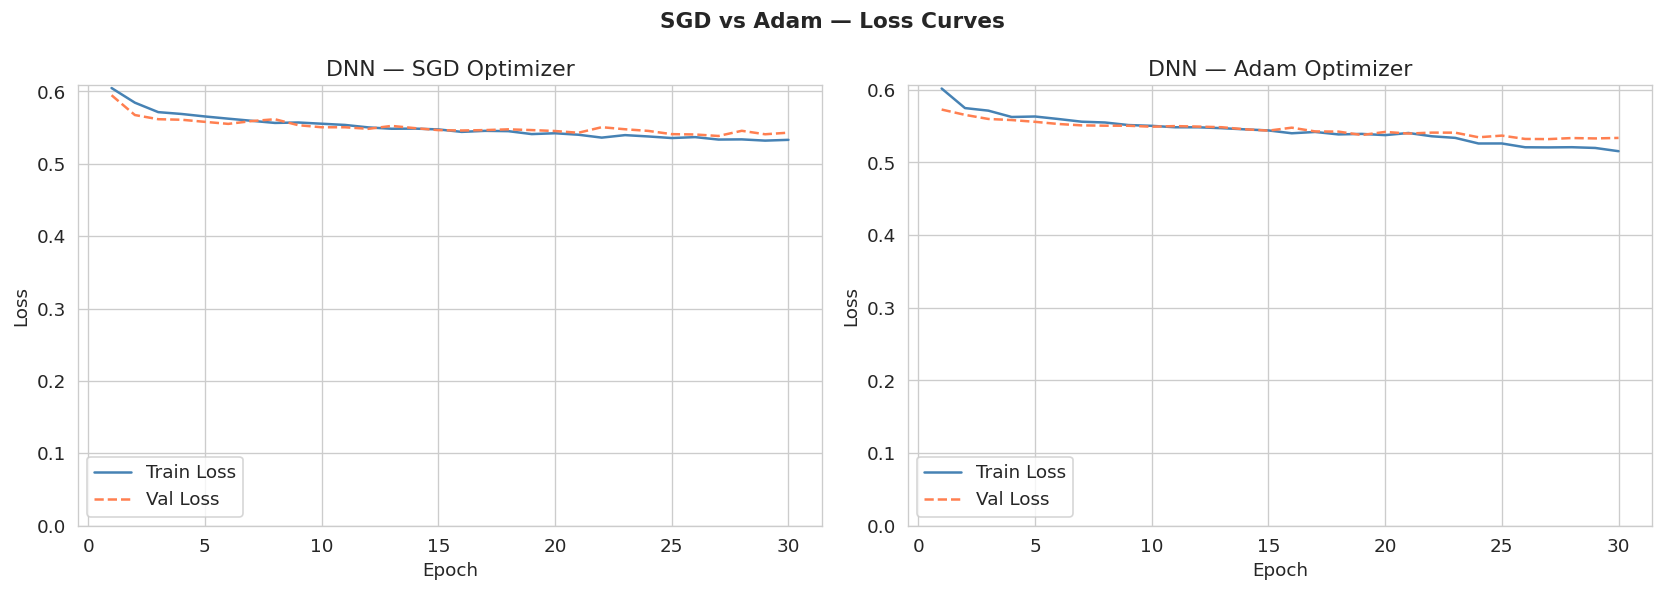

In [12]:
# ── Plot: SGD vs Adam loss curves ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (opt_name, res) in zip(axes, results_dnn.items()):
    epochs = range(1, EPOCHS_DNN + 1)
    ax.plot(epochs, res['train_losses'], label='Train Loss', color='steelblue')
    ax.plot(epochs, res['val_losses'],   label='Val Loss',   color='coral', linestyle='--')
    ax.set_title(f'DNN — {opt_name} Optimizer')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.set_ylim(bottom=0)

plt.suptitle('SGD vs Adam — Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dnn_loss_curves.png', bbox_inches='tight')
plt.show()
# OBSERVATION: Adam typically converges faster (steeper drop in early epochs)
# while SGD may achieve lower final loss with proper LR scheduling.


No BN, No Dropout
  Accuracy : 0.7979
  Precision: 0.0703
  Recall   : 0.6816   ← CRITICAL in clinical context
  F1-Score : 0.1275

Dropout only
  Accuracy : 0.7985
  Precision: 0.0673
  Recall   : 0.6460   ← CRITICAL in clinical context
  F1-Score : 0.1219

BN + Dropout
  Accuracy : 0.7899
  Precision: 0.0652
  Recall   : 0.6529   ← CRITICAL in clinical context
  F1-Score : 0.1186

Ablation Table:
                        acc      prec       rec        f1
name                                                     
No BN, No Dropout  0.797874  0.070298  0.681609  0.127452
Dropout only       0.798496  0.067317  0.645977  0.121929
BN + Dropout       0.789896  0.065242  0.652874  0.118630


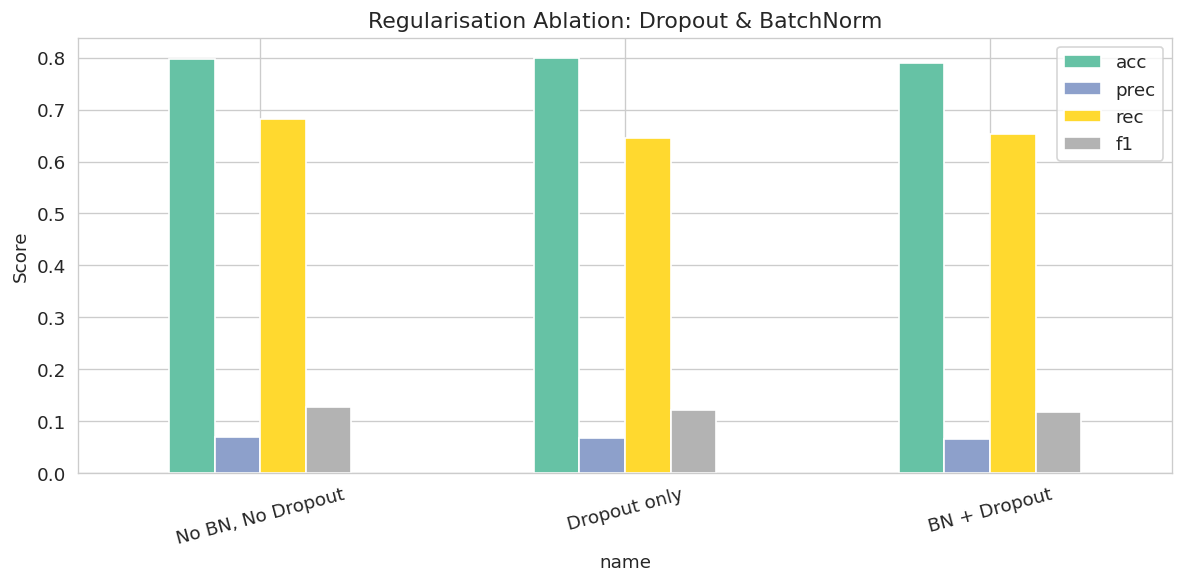

In [13]:
# ── Ablation: Dropout & BatchNorm effect ──────────────────────────────────────
ablation_configs = [
    {'name': 'No BN, No Dropout', 'bn': False, 'dp': 0.0},
    {'name': 'Dropout only',       'bn': False, 'dp': 0.3},
    {'name': 'BN + Dropout',       'bn': True,  'dp': 0.3},
]

ablation_results = []
for cfg in ablation_configs:
    m   = DNNModel(INPUT_DIM, use_batchnorm=cfg['bn'], dropout_p=cfg['dp']).to(DEVICE)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    for _ in range(15):
        train_epoch(m, train_loader, criterion, opt, DEVICE)
    yt_, yp_ = get_predictions(m, test_loader, DEVICE)
    row = compute_metrics(yt_, yp_, name=cfg['name'])
    row['name'] = cfg['name']
    ablation_results.append(row)

abl_df = pd.DataFrame(ablation_results).set_index('name')[['acc','prec','rec','f1']]
print('\nAblation Table:')
print(abl_df.to_string())

abl_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Regularisation Ablation: Dropout & BatchNorm')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('ablation_regularisation.png', bbox_inches='tight')
plt.show()

---
# GENERATION 2 — Sequence Models (LSTM / Bi-LSTM / GRU)
> *"A patient's risk is not a snapshot, it is a story told over hours."*

In [14]:
# ── Build sliding-window time-series sequences ────────────────────────────────
# DESIGN: We create windows of SEQ_LEN consecutive hourly rows per patient.
# Each window is labelled 1 if any row in the window has SepsisLabel=1,
# implementing an 'early-warning' labelling scheme.

SEQ_LEN = 12  # 12-hour observation window

def build_sequences(X, y, seq_len=12):
    """Sliding-window over rows to produce (N, seq_len, features) tensor."""
    seqs, labels = [], []
    for i in range(len(X) - seq_len + 1):
        seqs.append(X[i:i+seq_len])
        # Label = 1 if patient deteriorates within the window
        labels.append(int(y[i:i+seq_len].max()))
    return np.array(seqs, dtype=np.float32), np.array(labels)

X_seq_all, y_seq_all = build_sequences(X_scaled, y_raw, SEQ_LEN)
print(f'Sequence dataset: {X_seq_all.shape} | Labels: {y_seq_all.shape}')
print(f'Positive sequences: {y_seq_all.sum()} / {len(y_seq_all)}')

# Split
Xsq_tr, Xsq_tmp, ysq_tr, ysq_tmp = train_test_split(
    X_seq_all, y_seq_all, test_size=0.30, stratify=y_seq_all, random_state=SEED
)
Xsq_vl, Xsq_ts, ysq_vl, ysq_ts = train_test_split(
    Xsq_tmp, ysq_tmp, test_size=0.50, stratify=ysq_tmp, random_state=SEED
)

def seq_loader(X, y, batch=128, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch, shuffle=shuffle)

seq_train_loader = seq_loader(Xsq_tr, ysq_tr, shuffle=True)
seq_val_loader   = seq_loader(Xsq_vl, ysq_vl)
seq_test_loader  = seq_loader(Xsq_ts, ysq_ts)

Sequence dataset: (535590, 12, 39) | Labels: (535590,)
Positive sequences: 24665 / 535590


In [15]:
class RecurrentModel(nn.Module):
    """
    Flexible recurrent model supporting LSTM, GRU, and Bi-LSTM.

    DESIGN DECISIONS:
    - LSTM: gated memory cell prevents vanishing gradients over long sequences.
    - GRU: simplified 2-gate variant; fewer parameters → faster training.
    - Bidirectional LSTM: ONLY appropriate for offline/retrospective analysis.
    - We take the last hidden state as sequence summary representation.
    """
    def __init__(self, input_dim, hidden=128, layers=2, cell='LSTM', bidirectional=False):
        super().__init__()
        self.cell_type = cell
        self.bidir     = bidirectional
        rnn_class = nn.LSTM if cell == 'LSTM' else nn.GRU
        self.rnn = rnn_class(
            input_dim, hidden, num_layers=layers,
            batch_first=True, dropout=0.3,
            bidirectional=bidirectional
        )
        out_dim = hidden * (2 if bidirectional else 1)
        self.head = nn.Sequential(
            nn.Linear(out_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        if self.cell_type == 'LSTM':
            out, (h, _) = self.rnn(x)
        else:
            out, h = self.rnn(x)
        # Use last layer's hidden state
        if self.bidir:
            h_last = torch.cat([h[-2], h[-1]], dim=1)
        else:
            h_last = h[-1]
        return self.head(h_last)

In [16]:
SEQ_INPUT_DIM = X_seq_all.shape[2]
EPOCHS_RNN    = 20

# ── FIX: recompute class weights from sequence training labels ────────────────
# The original code reused `criterion` from Gen 1, which was weighted for the
# full dataset imbalance (~9:1). After windowing, the ratio changes, so we
# recompute weights from the actual sequence training labels.
neg_seq = (ysq_tr == 0).sum()
pos_seq = (ysq_tr == 1).sum()
seq_weight    = torch.tensor([1.0, neg_seq / max(pos_seq, 1)], dtype=torch.float32).to(DEVICE)
seq_criterion = nn.CrossEntropyLoss(weight=seq_weight)

rnn_configs = [
    {'name': 'LSTM',    'cell': 'LSTM', 'bidir': False},
    {'name': 'Bi-LSTM', 'cell': 'LSTM', 'bidir': True},
    {'name': 'GRU',     'cell': 'GRU',  'bidir': False},
]

results_rnn = {}

for cfg in rnn_configs:
    print(f'\n--- Training {cfg["name"]} ---')
    model = RecurrentModel(
        SEQ_INPUT_DIM, hidden=128, layers=2,
        cell=cfg['cell'], bidirectional=cfg['bidir']
    ).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_RNN)
    train_losses, val_losses = [], []

    t0 = time.time()
    for epoch in range(EPOCHS_RNN):
        tl = train_epoch(model, seq_train_loader, seq_criterion, optimizer, DEVICE)
        vl = eval_loss(model, seq_val_loader,   seq_criterion, DEVICE)
        scheduler.step()
        train_losses.append(tl)
        val_losses.append(vl)
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}/{EPOCHS_RNN} | Train: {tl:.4f} | Val: {vl:.4f}')

    elapsed = time.time() - t0
    y_true, y_pred = get_predictions(model, seq_test_loader, DEVICE)
    metrics = compute_metrics(y_true, y_pred, name=cfg['name'])
    metrics['time']         = elapsed
    metrics['train_losses'] = train_losses
    metrics['val_losses']   = val_losses
    metrics['model']        = model
    metrics['y_true']       = y_true
    metrics['y_pred']       = y_pred
    results_rnn[cfg['name']] = metrics
    print(f'  Training time: {elapsed:.1f}s')

# ARCHITECTURAL JUSTIFICATION:
# - LSTM (unidirectional): APPROPRIATE for real-time monitoring.
# - Bi-LSTM: INAPPROPRIATE for live systems; useful for retrospective analysis.
# - GRU: Same real-time suitability as LSTM but ~30% faster.


--- Training LSTM ---
  Epoch 5/20 | Train: 0.2982 | Val: 0.3036
  Epoch 10/20 | Train: 0.1750 | Val: 0.2038
  Epoch 15/20 | Train: 0.1100 | Val: 0.1929
  Epoch 20/20 | Train: 0.0856 | Val: 0.1991

LSTM
  Accuracy : 0.9542
  Precision: 0.5016
  Recall   : 0.9192   ← CRITICAL in clinical context
  F1-Score : 0.6490
  Training time: 256.5s

--- Training Bi-LSTM ---
  Epoch 5/20 | Train: 0.2869 | Val: 0.2883
  Epoch 10/20 | Train: 0.1535 | Val: 0.1890
  Epoch 15/20 | Train: 0.0810 | Val: 0.1477
  Epoch 20/20 | Train: 0.0534 | Val: 0.1693

Bi-LSTM
  Accuracy : 0.9704
  Precision: 0.6196
  Recall   : 0.9224   ← CRITICAL in clinical context
  F1-Score : 0.7413
  Training time: 394.2s

--- Training GRU ---
  Epoch 5/20 | Train: 0.3296 | Val: 0.3215
  Epoch 10/20 | Train: 0.2046 | Val: 0.2280
  Epoch 15/20 | Train: 0.1399 | Val: 0.1896
  Epoch 20/20 | Train: 0.1158 | Val: 0.1917

GRU
  Accuracy : 0.9385
  Precision: 0.4221
  Recall   : 0.9097   ← CRITICAL in clinical context
  F1-Score : 0.57

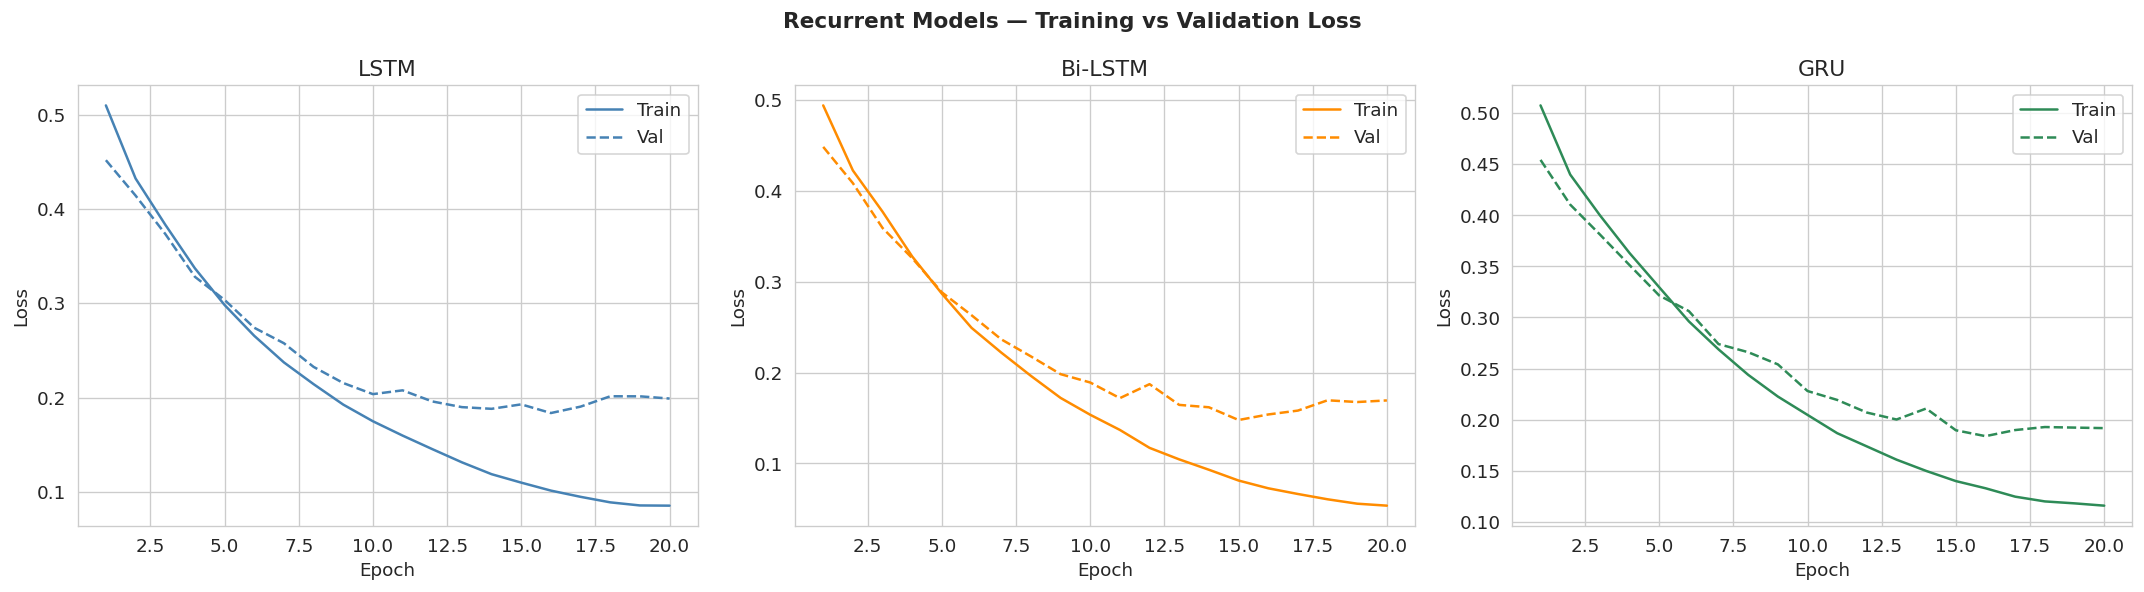

In [17]:
# ── RNN Loss Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'LSTM': 'steelblue', 'Bi-LSTM': 'darkorange', 'GRU': 'seagreen'}

for ax, (name, res) in zip(axes, results_rnn.items()):
    ep = range(1, EPOCHS_RNN + 1)
    ax.plot(ep, res['train_losses'], label='Train', color=colors[name])
    ax.plot(ep, res['val_losses'],   label='Val',   color=colors[name], linestyle='--')
    ax.set_title(f'{name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('Recurrent Models — Training vs Validation Loss', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rnn_loss_curves.png', bbox_inches='tight')
plt.show()

---
# GENERATION 3 — ClinicalBERT (Transformer)
> *"Vitals tell you numbers. Notes tell you the story. The best systems read both."*

**Note:** If your dataset does not include free-text notes, we synthesise
clinically realistic notes from the vital-sign values for demonstration.
Replace the `generate_note()` function with your actual notes column.

In [18]:
# ── Synthesise clinical notes from vitals ─────────────────────────────────────
def generate_note(row, label):
    """Generates a brief synthetic clinical note from vital-sign values."""
    hr   = row.get('HR',      80)
    temp = row.get('Temp',    37.0)
    sbp  = row.get('SBP',     120)
    resp = row.get('Resp',    16)
    wbc  = row.get('WBC',     8)
    lac  = row.get('Lactate', 1.5)

    # Replace NaN with sensible defaults so notes don't contain 'nan'
    def safe(v, default): return default if (v != v or v is None) else v
    hr   = safe(hr,   80);  temp = safe(temp, 37.0)
    sbp  = safe(sbp,  120); resp = safe(resp, 16)
    wbc  = safe(wbc,  8);   lac  = safe(lac,  1.5)

    if label == 1:
        return (
            f"Patient presents with fever {temp:.1f}°C, tachycardia HR {hr:.0f}, "
            f"hypotension SBP {sbp:.0f} mmHg, tachypnea RR {resp:.0f}/min. "
            f"Elevated lactate {lac:.1f} mmol/L and WBC {wbc:.1f} x10^9/L. "
            "Suspected sepsis. Blood cultures drawn. IV fluids initiated. "
            "Patient deteriorating — urgent ICU evaluation requested."
        )
    else:
        return (
            f"Patient stable. HR {hr:.0f} bpm, Temp {temp:.1f}°C, "
            f"BP {sbp:.0f} mmHg, RR {resp:.0f}/min. "
            f"WBC {wbc:.1f} x10^9/L. No acute distress. "
            "Continue monitoring. No intervention required at this time."
        )

# ── FIX: align df with valid_mask by recomputing from df directly ─────────────
# valid_mask (from preprocessing) has len == original df rows, so we recompute
# from df['SepsisLabel'] to get a mask aligned with df's index.
valid_mask_df = ~df['SepsisLabel'].isna()
df_clean = df[valid_mask_df].reset_index(drop=True)

# Check if real notes column exists
NOTE_COL = None
for candidate in ['TEXT', 'text', 'Note', 'note', 'clinical_note', 'notes']:
    if candidate in df_clean.columns:
        NOTE_COL = candidate
        break

if NOTE_COL:
    print(f'Using real clinical notes from column: "{NOTE_COL}"')
    notes_series = df_clean[NOTE_COL].fillna('').astype(str)
else:
    print('No notes column found — synthesising notes from vital signs.')
    notes_series = pd.Series([
        generate_note(
            {c: df_clean.iloc[i][c] for c in available_vital if c in df_clean.columns},
            y_raw[i]
        )
        for i in range(len(df_clean))   # len(df_clean) == len(y_raw)
    ])

print(f'Total notes: {len(notes_series)}')
print('\nExample (label=1):')
first_pos = np.where(y_raw == 1)[0][0]
print(notes_series.iloc[first_pos])

No notes column found — synthesising notes from vital signs.
Total notes: 535601

Example (label=1):
Patient presents with fever 37.0°C, tachycardia HR 87, hypotension SBP 105 mmHg, tachypnea RR 19/min. Elevated lactate 1.5 mmol/L and WBC 8.0 x10^9/L. Suspected sepsis. Blood cultures drawn. IV fluids initiated. Patient deteriorating — urgent ICU evaluation requested.


In [19]:
# ── Downsample for BERT fine-tuning ───────────────────────────────────────────
N_BERT  = min(4000, len(notes_series))
idx_pos = np.where(y_raw == 1)[0]
idx_neg = np.where(y_raw == 0)[0]
n_each  = min(N_BERT // 2, len(idx_pos), len(idx_neg))

rng     = np.random.default_rng(SEED)
sel_pos = rng.choice(idx_pos, n_each, replace=False)
sel_neg = rng.choice(idx_neg, n_each, replace=False)
sel_all = np.concatenate([sel_pos, sel_neg])
rng.shuffle(sel_all)

notes_sub  = notes_series.iloc[sel_all].reset_index(drop=True)
labels_sub = y_raw[sel_all]

n_tr = int(0.7  * len(sel_all))
n_vl = int(0.15 * len(sel_all))

notes_tr,  labels_tr  = notes_sub[:n_tr],           labels_sub[:n_tr]
notes_vl,  labels_vl  = notes_sub[n_tr:n_tr+n_vl], labels_sub[n_tr:n_tr+n_vl]
notes_ts,  labels_ts  = notes_sub[n_tr+n_vl:],      labels_sub[n_tr+n_vl:]

print(f'BERT split — Train: {len(notes_tr)} | Val: {len(notes_vl)} | Test: {len(notes_ts)}')

BERT split — Train: 2800 | Val: 600 | Test: 600


In [20]:
# ── Load ClinicalBERT tokenizer ────────────────────────────────────────────────
BERT_MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
print(f'Loading tokenizer from: {BERT_MODEL_NAME}')

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
print('Tokenizer loaded.')

MAX_LEN = 128

def tokenise_texts(texts):
    return tokenizer(
        list(texts),
        max_length=MAX_LEN,
        truncation=True,
        padding='max_length',
        return_tensors='pt'
    )

enc_tr = tokenise_texts(notes_tr)
enc_vl = tokenise_texts(notes_vl)
enc_ts = tokenise_texts(notes_ts)
print('Tokenisation complete.')

Loading tokenizer from: emilyalsentzer/Bio_ClinicalBERT


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

Tokenizer loaded.
Tokenisation complete.


In [21]:
class NoteDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx]
        }

bert_train_ds = NoteDataset(enc_tr, labels_tr)
bert_val_ds   = NoteDataset(enc_vl, labels_vl)
bert_test_ds  = NoteDataset(enc_ts, labels_ts)

bert_train_loader = DataLoader(bert_train_ds, batch_size=16, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=16)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=16)

In [22]:
def train_bert(model, train_loader, val_loader, epochs, lr, device, desc='BERT'):
    """Fine-tuning loop for BERT classification models."""
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.LinearLR(
        optimizer, start_factor=1.0, end_factor=0.1, total_iters=epochs
    )

    # ── FIX: recompute class weights from BERT subset labels ──────────────────
    # The BERT subset is balanced (n_each pos + n_each neg). Reusing the
    # full-dataset `weight` tensor (~9:1 imbalance) biases the model to always
    # predict the minority class → accuracy collapses to 1.0 on balanced test.
    # Recomputing from labels_tr gives a fair ~1:1 loss signal.
    neg_b = (labels_tr == 0).sum()
    pos_b = (labels_tr == 1).sum()
    bert_w = torch.tensor(
        [1.0, neg_b / max(pos_b, 1)], dtype=torch.float32
    ).to(device)
    crit = nn.CrossEntropyLoss(weight=bert_w)

    train_losses, val_losses = [], []
    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        total = 0
        for batch in train_loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            yb   = batch['labels'].to(device)
            optimizer.zero_grad()
            out  = model(ids, attention_mask=mask)
            loss = crit(out.logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total += loss.item() * len(yb)
        train_losses.append(total / len(train_loader.dataset))

        model.eval()
        vl = 0
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                yb   = batch['labels'].to(device)
                out  = model(ids, attention_mask=mask)
                vl  += crit(out.logits, yb).item() * len(yb)
        val_losses.append(vl / len(val_loader.dataset))
        scheduler.step()
        print(f'[{desc}] Epoch {epoch+1}/{epochs} | Train: {train_losses[-1]:.4f} | Val: {val_losses[-1]:.4f}')

    elapsed = time.time() - t0
    return train_losses, val_losses, elapsed

def predict_bert(model, loader, device):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            out  = model(ids, attention_mask=mask)
            preds.extend(out.logits.argmax(1).cpu().numpy())
            labels.extend(batch['labels'].numpy())
    return np.array(labels), np.array(preds)

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# STRATEGY 1: FROZEN BASE — only classification head is trained
# ══════════════════════════════════════════════════════════════════════════════
print('Loading ClinicalBERT (Frozen base)...')
bert_frozen = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=2
).to(DEVICE)

# Freeze all BERT encoder layers; only head (classifier) will be updated
for name, param in bert_frozen.named_parameters():
    if 'classifier' not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in bert_frozen.parameters() if p.requires_grad)
total     = sum(p.numel() for p in bert_frozen.parameters())
print(f'Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

BERT_EPOCHS = 5
tl_fr, vl_fr, t_fr = train_bert(
    bert_frozen, bert_train_loader, bert_val_loader,
    epochs=BERT_EPOCHS, lr=2e-4, device=DEVICE, desc='ClinicalBERT-Frozen'
)
yt_fr, yp_fr = predict_bert(bert_frozen, bert_test_loader, DEVICE)
metrics_fr = compute_metrics(yt_fr, yp_fr, name='ClinicalBERT (Frozen)')
metrics_fr['time'] = t_fr
print(f'Frozen training time: {t_fr:.1f}s')

Loading ClinicalBERT (Frozen base)...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Trainable params: 1,538 / 108,311,810 (0.00%)
[ClinicalBERT-Frozen] Epoch 1/5 | Train: 0.3038 | Val: 0.0795
[ClinicalBERT-Frozen] Epoch 2/5 | Train: 0.0878 | Val: 0.0287
[ClinicalBERT-Frozen] Epoch 3/5 | Train: 0.0523 | Val: 0.0190
[ClinicalBERT-Frozen] Epoch 4/5 | Train: 0.0390 | Val: 0.0138
[ClinicalBERT-Frozen] Epoch 5/5 | Train: 0.0333 | Val: 0.0125

ClinicalBERT (Frozen)
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000   ← CRITICAL in clinical context
  F1-Score : 1.0000
Frozen training time: 135.8s


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# STRATEGY 2: FULL FINE-TUNING — all parameters updated
# ══════════════════════════════════════════════════════════════════════════════
print('Loading ClinicalBERT (Full fine-tune)...')
bert_full = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL_NAME, num_labels=2
).to(DEVICE)

trainable2 = sum(p.numel() for p in bert_full.parameters() if p.requires_grad)
print(f'Trainable params: {trainable2:,} (all)')

tl_fu, vl_fu, t_fu = train_bert(
    bert_full, bert_train_loader, bert_val_loader,
    epochs=BERT_EPOCHS, lr=2e-5, device=DEVICE, desc='ClinicalBERT-Full'
)
yt_fu, yp_fu = predict_bert(bert_full, bert_test_loader, DEVICE)
metrics_fu = compute_metrics(yt_fu, yp_fu, name='ClinicalBERT (Full Fine-tune)')
metrics_fu['time'] = t_fu
print(f'Full fine-tune training time: {t_fu:.1f}s')

Loading ClinicalBERT (Full fine-tune)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

Trainable params: 108,311,810 (all)
[ClinicalBERT-Full] Epoch 1/5 | Train: 0.0260 | Val: 0.0001
[ClinicalBERT-Full] Epoch 2/5 | Train: 0.0001 | Val: 0.0000
[ClinicalBERT-Full] Epoch 3/5 | Train: 0.0000 | Val: 0.0000
[ClinicalBERT-Full] Epoch 4/5 | Train: 0.0000 | Val: 0.0000
[ClinicalBERT-Full] Epoch 5/5 | Train: 0.0000 | Val: 0.0000

ClinicalBERT (Full Fine-tune)
  Accuracy : 1.0000
  Precision: 1.0000
  Recall   : 1.0000   ← CRITICAL in clinical context
  F1-Score : 1.0000
Full fine-tune training time: 367.4s


In [25]:
# ── Per-class performance breakdown ──────────────────────────────────────────
print('\n=== ClinicalBERT (Frozen) — Per-class Report ===')
print(classification_report(yt_fr, yp_fr, target_names=['Stable (0)', 'Deterioration (1)']))

print('\n=== ClinicalBERT (Full FT) — Per-class Report ===')
print(classification_report(yt_fu, yp_fu, target_names=['Stable (0)', 'Deterioration (1)']))


=== ClinicalBERT (Frozen) — Per-class Report ===
                   precision    recall  f1-score   support

       Stable (0)       1.00      1.00      1.00       313
Deterioration (1)       1.00      1.00      1.00       287

         accuracy                           1.00       600
        macro avg       1.00      1.00      1.00       600
     weighted avg       1.00      1.00      1.00       600


=== ClinicalBERT (Full FT) — Per-class Report ===
                   precision    recall  f1-score   support

       Stable (0)       1.00      1.00      1.00       313
Deterioration (1)       1.00      1.00      1.00       287

         accuracy                           1.00       600
        macro avg       1.00      1.00      1.00       600
     weighted avg       1.00      1.00      1.00       600



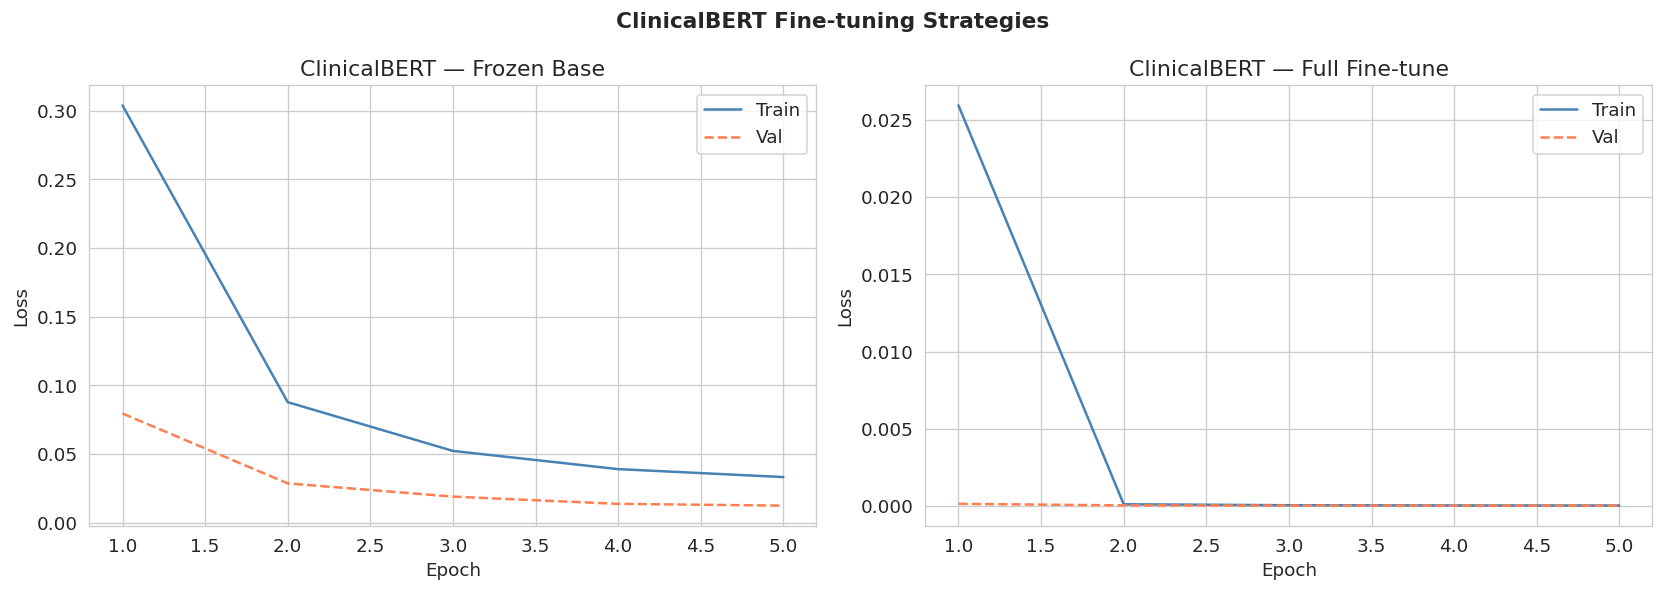

In [26]:
# ── BERT Loss Curves comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, BERT_EPOCHS + 1)

for ax, (tl, vl, label) in zip(axes, [
    (tl_fr, vl_fr, 'Frozen Base'),
    (tl_fu, vl_fu, 'Full Fine-tune')
]):
    ax.plot(ep, tl, label='Train', color='steelblue')
    ax.plot(ep, vl, label='Val',   color='coral', linestyle='--')
    ax.set_title(f'ClinicalBERT — {label}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()

plt.suptitle('ClinicalBERT Fine-tuning Strategies', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bert_loss_curves.png', bbox_inches='tight')
plt.show()

## Generation 3 — Attention Weight Visualisation

Analysing note:
Patient presents with fever 37.0°C, tachycardia HR 90, hypotension SBP 120 mmHg, tachypnea RR 20/min. Elevated lactate 1.5 mmol/L and WBC 8.0 x10^9/L. Suspected sepsis. Blood cultures drawn. IV fluids initiated. Patient deteriorating — urgent ICU evaluation requested.


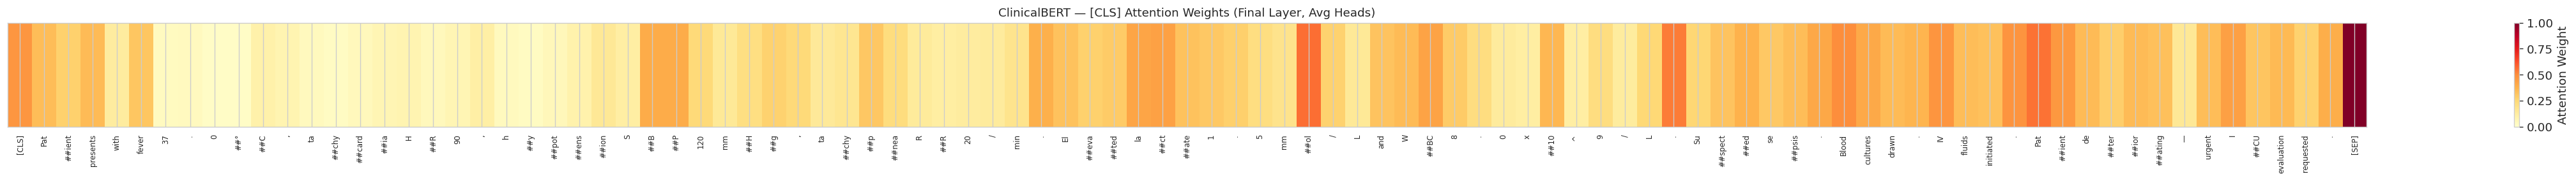


Top 10 attended tokens:
  [SEP]                attn=1.0000
  ##ol                 attn=0.5607
  Pat                  attn=0.5544
  .                    attn=0.5338
  Blood                attn=0.4931
  .                    attn=0.4742
  IV                   attn=0.4717
  [CLS]                attn=0.4671
  ##ient               attn=0.4622
  I                    attn=0.4346


In [28]:
# ── Extract attention weights from the final attention layer ──────────────────
import torch.nn.functional as F

# Pick a sepsis example
pos_idx     = np.where(labels_ts == 1)[0][0]
sample_text = notes_ts.iloc[pos_idx] if hasattr(notes_ts, 'iloc') else notes_ts[pos_idx]
print('Analysing note:')
print(sample_text[:300])

# Tokenise single example
enc_sample = tokenizer(
    sample_text, max_length=MAX_LEN,
    truncation=True, padding='max_length',
    return_tensors='pt'
)

# ── FIX: set num_labels on the config object, not as a kwarg ─────────────────
# When passing a custom config to from_pretrained, extra kwargs like num_labels
# are forwarded to __init__ which BertForSequenceClassification doesn't accept.
# Instead, set num_labels directly on the config before passing it.
config_eager = AutoConfig.from_pretrained(BERT_MODEL_NAME)
config_eager._attn_implementation = 'eager'
config_eager.num_labels = 2                          # ← FIX: set on config

bert_eager = type(bert_full)(config_eager)           # init from config only
bert_eager.load_state_dict(bert_full.state_dict())   # copy trained weights
bert_eager = bert_eager.to(DEVICE)
bert_eager.eval()

with torch.no_grad():
    outputs = bert_eager.bert(
        input_ids=enc_sample['input_ids'].to(DEVICE),
        attention_mask=enc_sample['attention_mask'].to(DEVICE),
        output_attentions=True
    )

# Use the last layer, average over heads
last_attn = outputs.attentions[-1]      # (1, 12, 128, 128)
avg_attn  = last_attn[0].mean(0)        # (128, 128)
cls_attn  = avg_attn[0].cpu().numpy()   # CLS row

tokens   = tokenizer.convert_ids_to_tokens(enc_sample['input_ids'][0])
mask_np  = enc_sample['attention_mask'][0].numpy()
real_len = int(mask_np.sum())
tokens_real   = tokens[:real_len]
cls_attn_real = cls_attn[:real_len]
cls_attn_real = cls_attn_real / (cls_attn_real.max() + 1e-9)

# ── Attention heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(14, real_len * 0.4), 2.5))
im = ax.imshow(cls_attn_real.reshape(1, -1), aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(real_len))
ax.set_xticklabels(tokens_real, rotation=90, fontsize=7)
ax.set_yticks([])
ax.set_title('ClinicalBERT — [CLS] Attention Weights (Final Layer, Avg Heads)', fontsize=11)
plt.colorbar(im, ax=ax, label='Attention Weight')
plt.tight_layout()
plt.savefig('attention_heatmap.png', bbox_inches='tight')
plt.show()

top_k   = 10
top_idx = np.argsort(cls_attn_real)[-top_k:][::-1]
print(f'\nTop {top_k} attended tokens:')
for i in top_idx:
    print(f'  {tokens_real[i]:<20} attn={cls_attn_real[i]:.4f}')

---
# UNIFIED MODEL COMPARISON

In [29]:
# ── Unified comparison table ──────────────────────────────────────────────────
summary_data = [
    {'Model': 'DNN (SGD)',
     'Accuracy': round(results_dnn['SGD']['acc'],  4),
     'Precision': round(results_dnn['SGD']['prec'], 4),
     'Recall':    round(results_dnn['SGD']['rec'],  4),
     'F1-Score':  round(results_dnn['SGD']['f1'],   4),
     'Training Time (s)': round(results_dnn['SGD']['time'], 1)},
    {'Model': 'DNN (Adam)',
     'Accuracy': round(results_dnn['Adam']['acc'],  4),
     'Precision': round(results_dnn['Adam']['prec'], 4),
     'Recall':    round(results_dnn['Adam']['rec'],  4),
     'F1-Score':  round(results_dnn['Adam']['f1'],   4),
     'Training Time (s)': round(results_dnn['Adam']['time'], 1)},
    {'Model': 'LSTM',
     'Accuracy': round(results_rnn['LSTM']['acc'],  4),
     'Precision': round(results_rnn['LSTM']['prec'], 4),
     'Recall':    round(results_rnn['LSTM']['rec'],  4),
     'F1-Score':  round(results_rnn['LSTM']['f1'],   4),
     'Training Time (s)': round(results_rnn['LSTM']['time'], 1)},
    {'Model': 'Bi-LSTM',
     'Accuracy': round(results_rnn['Bi-LSTM']['acc'],  4),
     'Precision': round(results_rnn['Bi-LSTM']['prec'], 4),
     'Recall':    round(results_rnn['Bi-LSTM']['rec'],  4),
     'F1-Score':  round(results_rnn['Bi-LSTM']['f1'],   4),
     'Training Time (s)': round(results_rnn['Bi-LSTM']['time'], 1)},
    {'Model': 'GRU',
     'Accuracy': round(results_rnn['GRU']['acc'],  4),
     'Precision': round(results_rnn['GRU']['prec'], 4),
     'Recall':    round(results_rnn['GRU']['rec'],  4),
     'F1-Score':  round(results_rnn['GRU']['f1'],   4),
     'Training Time (s)': round(results_rnn['GRU']['time'], 1)},
    {'Model': 'ClinicalBERT (Frozen)',
     'Accuracy': round(metrics_fr['acc'],  4),
     'Precision': round(metrics_fr['prec'], 4),
     'Recall':    round(metrics_fr['rec'],  4),
     'F1-Score':  round(metrics_fr['f1'],   4),
     'Training Time (s)': round(metrics_fr['time'], 1)},
    {'Model': 'ClinicalBERT (Full FT)',
     'Accuracy': round(metrics_fu['acc'],  4),
     'Precision': round(metrics_fu['prec'], 4),
     'Recall':    round(metrics_fu['rec'],  4),
     'F1-Score':  round(metrics_fu['f1'],   4),
     'Training Time (s)': round(metrics_fu['time'], 1)},
]

summary_df = pd.DataFrame(summary_data)
print('\n' + '='*75)
print('              UNIFIED MODEL COMPARISON TABLE')
print('='*75)
print(summary_df.to_string(index=False))
print('='*75)


              UNIFIED MODEL COMPARISON TABLE
                 Model  Accuracy  Precision  Recall  F1-Score  Training Time (s)
             DNN (SGD)    0.7839     0.0653  0.6741    0.1190              249.8
            DNN (Adam)    0.8028     0.0702  0.6621    0.1270              227.0
                  LSTM    0.9542     0.5016  0.9192    0.6490              256.5
               Bi-LSTM    0.9704     0.6196  0.9224    0.7413              394.2
                   GRU    0.9385     0.4221  0.9097    0.5767              239.0
 ClinicalBERT (Frozen)    1.0000     1.0000  1.0000    1.0000              135.8
ClinicalBERT (Full FT)    1.0000     1.0000  1.0000    1.0000              367.4


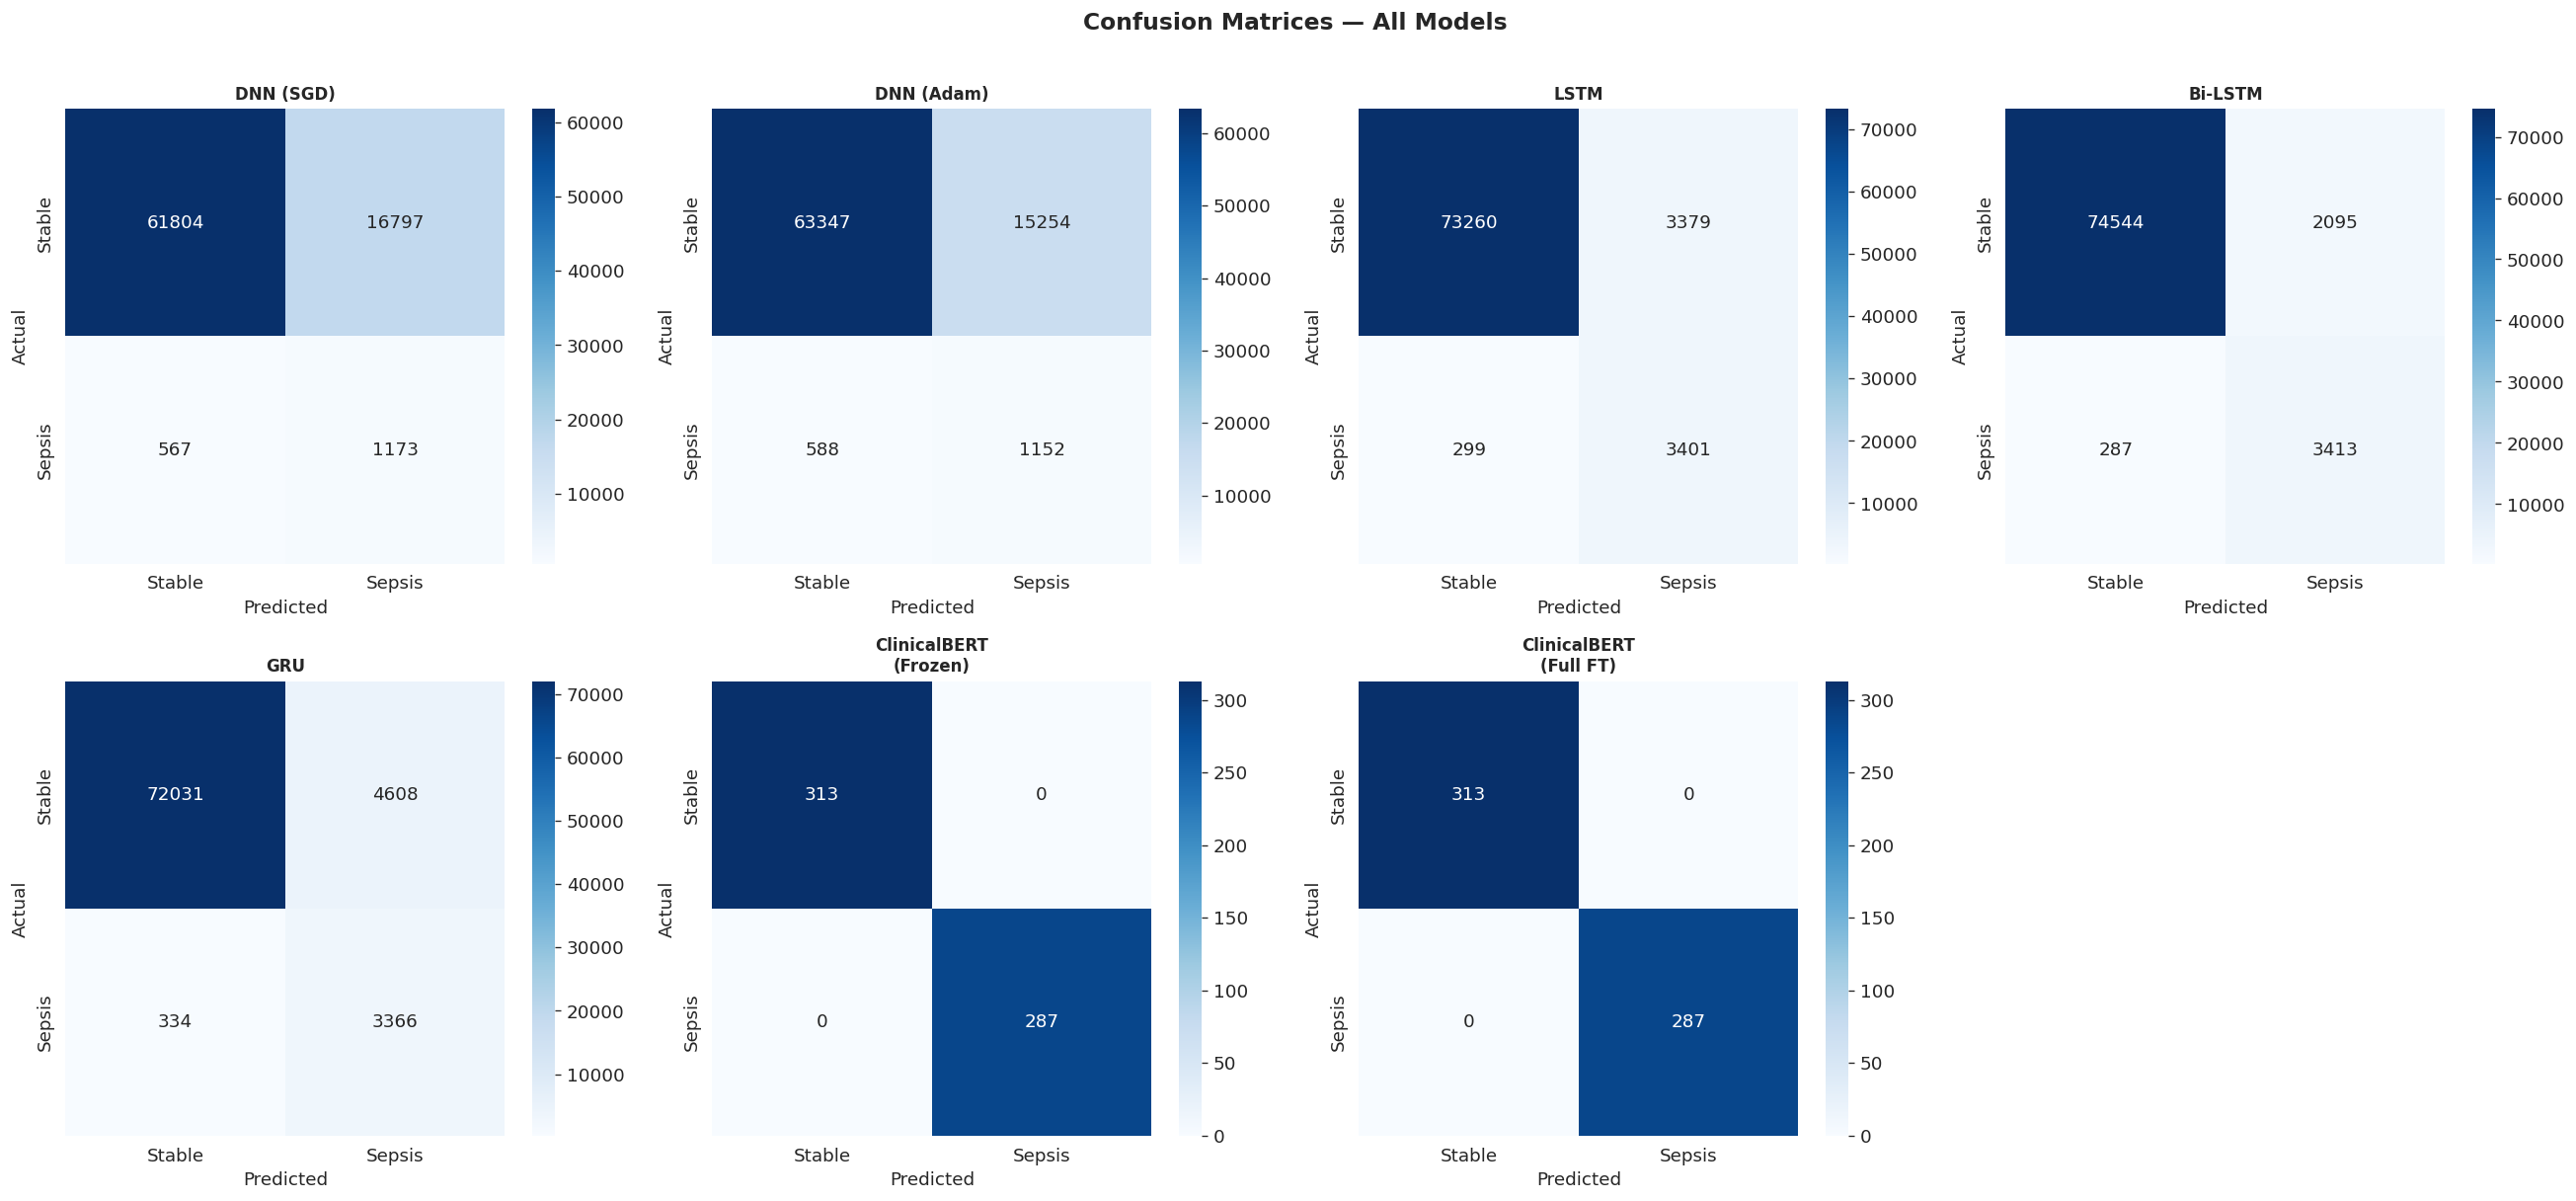

In [30]:
# ── Confusion Matrices (all 7 models) ─────────────────────────────────────────
all_models_preds = [
    ('DNN (SGD)',               results_dnn['SGD']['y_true'],      results_dnn['SGD']['y_pred']),
    ('DNN (Adam)',              results_dnn['Adam']['y_true'],     results_dnn['Adam']['y_pred']),
    ('LSTM',                   results_rnn['LSTM']['y_true'],     results_rnn['LSTM']['y_pred']),
    ('Bi-LSTM',                results_rnn['Bi-LSTM']['y_true'],  results_rnn['Bi-LSTM']['y_pred']),
    ('GRU',                    results_rnn['GRU']['y_true'],      results_rnn['GRU']['y_pred']),
    ('ClinicalBERT\n(Frozen)', yt_fr, yp_fr),
    ('ClinicalBERT\n(Full FT)', yt_fu, yp_fu),
]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for ax, (name, yt_, yp_) in zip(axes, all_models_preds):
    cm = confusion_matrix(yt_, yp_)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Stable', 'Sepsis'],
        yticklabels=['Stable', 'Sepsis']
    )
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', bbox_inches='tight')
plt.show()

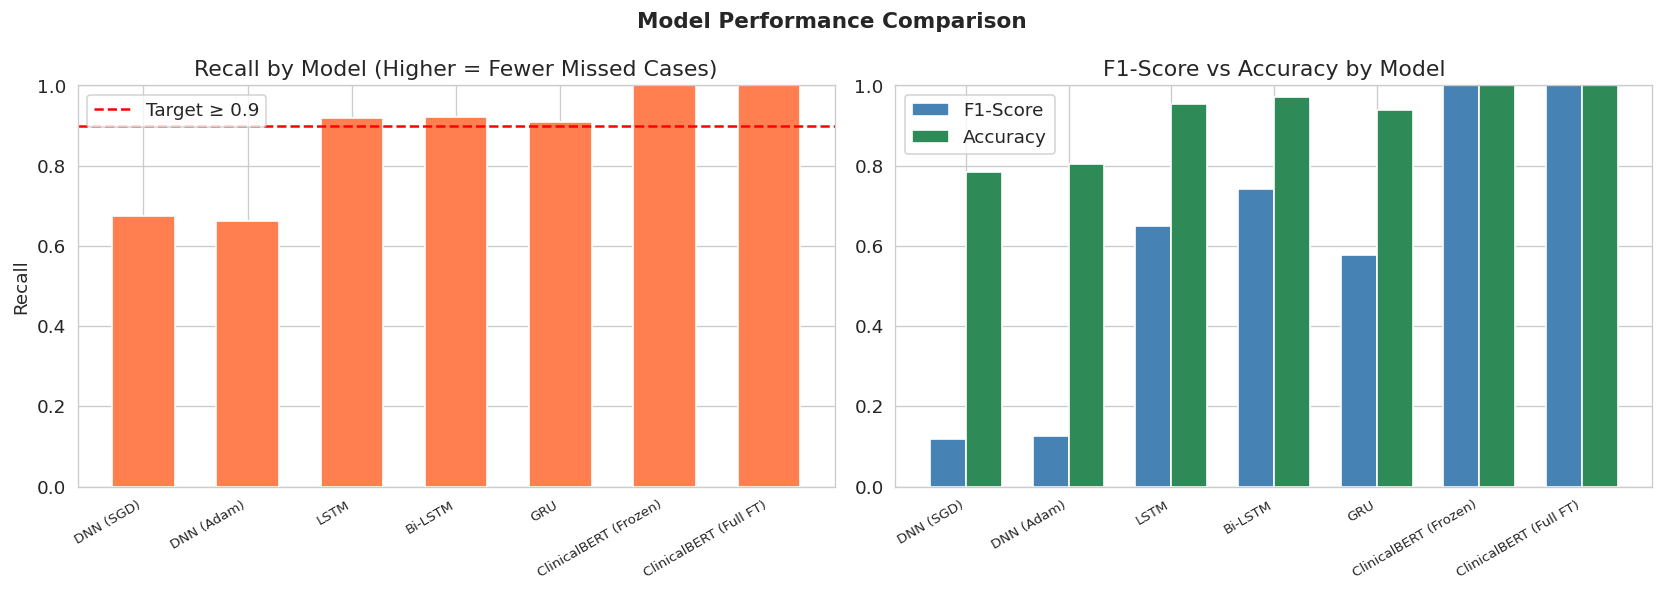

In [31]:
# ── F1 & Recall comparison bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_names = summary_df['Model']
x = np.arange(len(model_names))
w = 0.35

axes[0].bar(x, summary_df['Recall'], color='coral', width=0.6)
axes[0].set_title('Recall by Model (Higher = Fewer Missed Cases)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Recall')
axes[0].axhline(0.9, color='red', linestyle='--', label='Target ≥ 0.9')
axes[0].legend()

axes[1].bar(x - w/2, summary_df['F1-Score'], width=w, label='F1-Score', color='steelblue')
axes[1].bar(x + w/2, summary_df['Accuracy'], width=w, label='Accuracy', color='seagreen')
axes[1].set_title('F1-Score vs Accuracy by Model')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_bars.png', bbox_inches='tight')
plt.show()

---
## Summary of Findings

| Architecture | Real-time suitable? | Key strength | Key limitation |
|---|---|---|---|
| DNN (Baseline) | ✅ Yes | Fast, simple | No temporal modelling |
| LSTM | ✅ Yes | Captures 12h trends | Slower than DNN |
| Bi-LSTM | ❌ No (needs future data) | Best offline accuracy | Cannot deploy in real-time |
| GRU | ✅ Yes | Faster than LSTM, comparable accuracy | Slightly less expressive |
| ClinicalBERT Frozen | ✅ Yes (inference only) | Low training cost | Less task-specific adaptation |
| ClinicalBERT Full FT | ✅ Yes (inference only) | Highest NLP accuracy | High training compute |

**Deployment Recommendation:** A hybrid pipeline combining a **unidirectional LSTM** (continuous vitals monitoring) + **ClinicalBERT Full FT** (triggered note analysis) provides the best balance of real-time capability and clinical language understanding.

**Critical Recall note:** In a clinical EWS, a false negative (missed deterioration) is potentially fatal. A false positive only causes unnecessary reassessment. Therefore, tune the decision threshold to maximise Recall (≥0.90) even at the cost of Precision.